Импорт зависимостей

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Достаем данные


In [52]:
train_set = pd.read_csv('data/train.csv')
train_set.shape
train_set.info()
train_set.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Создаем копию и проверяем данные на пропуска

In [53]:
train_set_copy = train_set.copy()
missing = train_set_copy.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Так как в основе видно категориальные признаки - то Nan не ошибка, а осмысленное значение. Заполняем пропуски

In [54]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

for col in none_cols:
    train_set_copy[col] = train_set_copy[col].fillna('None')

Числовые признаки заполняем медианой

In [55]:
train_set_copy['LotFrontage'] = train_set_copy['LotFrontage'].fillna(train_set_copy['LotFrontage'].median())
train_set_copy['GarageYrBlt'].fillna(0)
train_set_copy['MasVnrArea'].fillna(0)
train_set_copy['MasVnrType'].fillna('None')
train_set_copy['Electrical'].fillna(train_set_copy['Electrical'].mode()[0])

0       SBrkr
1       SBrkr
2       SBrkr
3       SBrkr
4       SBrkr
        ...  
1455    SBrkr
1456    SBrkr
1457    SBrkr
1458    FuseA
1459    SBrkr
Name: Electrical, Length: 1460, dtype: str

Проверяем пропуски

In [56]:
train_set_copy.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

Просматриваем распределение домов

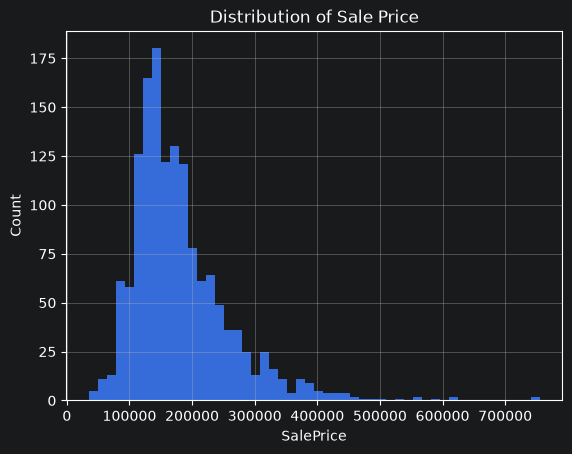

In [57]:
train_set_copy['SalePrice'].hist(bins=50)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.title("Distribution of Sale Price")
plt.show()

Большинство домов сосредоточено в диапазоне 100-250 тысяч, но есть небольшое количество домов создающих хвост. Так называемый скос вправо. Посчитаем асимметрию вправо

In [58]:
train_set_copy['SalePrice'].skew()

np.float64(1.8828757597682129)

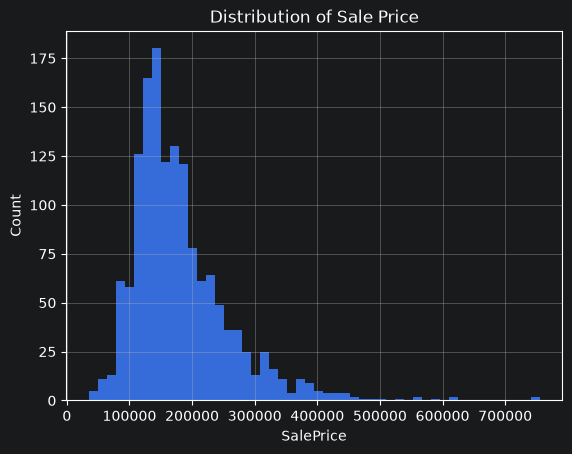

In [59]:
train_set_copy['SalePrice'].hist(bins=50)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.title("Distribution of Sale Price")
plt.show()

Логарифмирование необходимо, по причине того что многие модели и метрики регрессии чувствительны к такой асимметрии - большие значения будут непропорционально влиять на обучение. Логарифмирование сожмет правый хвост и приблизит распределение к нормальному

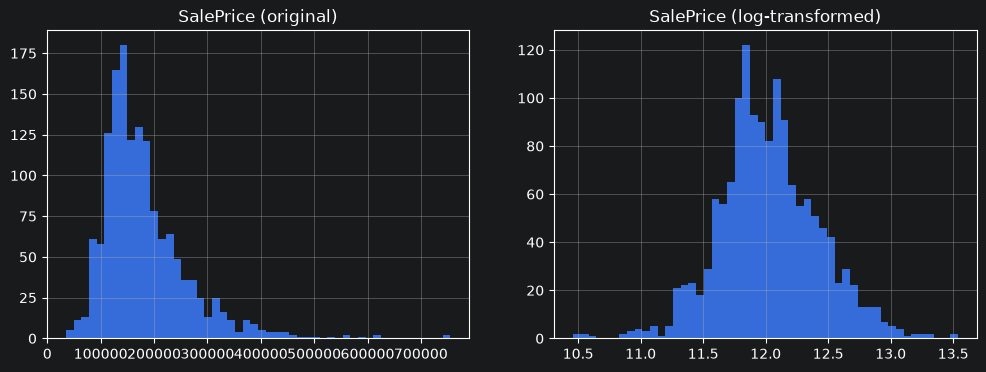

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_set_copy['SalePrice'].hist(bins=50, ax=axes[0])
axes[0].set_title("SalePrice (original)")
np.log1p(train_set_copy['SalePrice']).hist(bins=50, ax=axes[1])
axes[1].set_title("SalePrice (log-transformed)")
plt.show()

Сохраняем преобразованную колонку

In [61]:
train_set_copy['SalePrice_log'] = np.log1p(train_set_copy['SalePrice'])

Создаем 4 признака


In [62]:
train_set_copy['TotalSF'] = (
    train_set_copy['TotalBsmtSF'] +
    train_set_copy['1stFlrSF'] +
    train_set_copy['2ndFlrSF']
)

Возраст дома на момент продажи

In [63]:
train_set_copy['HouseAge'] = train_set_copy['YrSold'] - train_set_copy['YearBuilt']

Возраст последнего ремонта

In [64]:
train_set_copy['YearsSinceRemodel'] = train_set_copy['YrSold'] - train_set_copy['YearRemodAdd']

Общее количество ванных комнат

In [65]:
train_set_copy['TotalBath'] = (
    train_set_copy['FullBath'] + 0.5 * train_set_copy['HalfBath'] +
    train_set_copy['BsmtFullBath'] + 0.5 * train_set_copy['BsmtHalfBath']
)

Проверка, помогли ли новые признаки

In [66]:
new_feature = ['TotalSF','HouseAge','YearsSinceRemodel','TotalBath']
train_set_copy[new_feature + ['SalePrice_log']].corr()['SalePrice_log']

TotalSF              0.777297
HouseAge            -0.587290
YearsSinceRemodel   -0.568136
TotalBath            0.673011
SalePrice_log        1.000000
Name: SalePrice_log, dtype: float64

Кодирование категориальных признаков

In [67]:
quality_map = {'None': 0, 'Po': 1, 'Fa'  : 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in ordinal_cols:
    train_set_copy[col] = train_set_copy[col].map(quality_map)

In [68]:
train_set_copy[ordinal_cols].isnull().sum()

ExterQual      0
ExterCond      0
BsmtQual       0
BsmtCond       0
HeatingQC      0
KitchenQual    0
FireplaceQu    0
GarageQual     0
GarageCond     0
dtype: int64

one-hot encoding номинальных признаков

Теперь кодируем оставшиеся категориальные колонки без естественного порядка

In [69]:
nominal_cols = train_set_copy.select_dtypes(include='object').columns.tolist()
print(nominal_cols)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


C:\Users\mikha\AppData\Local\Temp\ipykernel_16160\404964473.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  nominal_cols = train_set_copy.select_dtypes(include='object').columns.tolist()


In [70]:
train_set_copy = pd.get_dummies(train_set_copy, columns=nominal_cols, drop_first=True)

Финальная проверка

In [72]:
train_set_copy.isnull().sum().sum()


np.int64(89)

In [73]:
train_set_copy.select_dtypes(include='object').columns


Index([], dtype='str')

In [74]:
train_set_copy.shape

(1460, 237)

In [75]:
missing_after = train_set_copy.isnull().sum()
missing_after[missing_after > 0]

MasVnrArea      8
GarageYrBlt    81
dtype: int64

In [76]:
train_set_copy['GarageYrBlt'] = train_set_copy['GarageYrBlt'].fillna(0)
train_set_copy['MasVnrArea'] = train_set_copy['MasVnrArea'].fillna(0)

In [77]:
train_set_copy.isnull().sum().sum()

np.int64(0)